<a href="https://colab.research.google.com/github/MrCherveN/Machine-Learning--4-0_HomeTasks/blob/main/HW_%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC%D0%B8_%D0%BA%D0%BB%D0%B0%D1%81%D1%82%D0%B5%D1%80%D0%B8%D0%B7%D0%B0%D1%86%D1%96%D1%97.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [1]:
import pandas as pd

df = pd.read_csv('/content/marketing_campaign.csv', sep='\t')


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

In [3]:
df['Income'] = df['Income'].fillna(df['Income'].median())

In [4]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


***Відповідь:***
- Пропуски присутні лише у змінній Income та становлять незначну частку вибірки.
- Для заповнення пропущених значень було обрано медіану. Перевага медіани над середнім полягає в тому, що вона не спотворює відстані між об'єктами, що важливо для алгоритмів кластерізації, які чутливі до викидів.

**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

In [5]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


Відберемо колонки з категоріальним типом даних:

In [6]:
df.select_dtypes(include=object).columns

Index(['Education', 'Marital_Status', 'Dt_Customer'], dtype='object')

Оскільки алгоритми кластерізації працють х числами, то:

 - для колонки Education застосуємо механізм обробки значень Ordinal Encoding, оскльіки рівень освіти все ж має певну ієрархію, яка буде впливати на роботу алгоритму кластерізації;
 - для колонки Marital_Status застосуємо механізм обробки значень One-Hot Encoding;
 - для колонки з датою (Dt_Customer: Дата реєстрації клієнта у компанії) можна виділити два значення - рік реєстрації тп кількість днів від першої реєстрації (запусу в наборі) до дати реєстрації клієнта.

In [7]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

In [8]:
df.Education.value_counts()

,count
Education,
Graduation,1127
PhD,486
Master,370
2n Cycle,203
Basic,54


In [9]:
ordenc = OrdinalEncoder(categories=[['Basic', '2n Cycle', 'Graduation', 'Master', 'PhD']])
ordenc.fit(df[['Education']])
df['Education_Level'] = ordenc.transform(df[['Education']])

In [10]:
df.Marital_Status.value_counts()

,count
Marital_Status,
Married,864
Together,580
Single,480
Divorced,232
Widow,77
Alone,3
Absurd,2
YOLO,2


In [11]:
ohe_columns = ['Marital_Status']
ohenc = OneHotEncoder()
ohenc.fit(df[ohe_columns])

one_hot = ohenc.transform(df[ohe_columns]).toarray()
df[ohenc.categories_[0]] = one_hot


In [12]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)
df['Customer_Year'] = df['Dt_Customer'].dt.year
df['Customer_Registration_Days'] = (df['Dt_Customer'].max() - df['Dt_Customer']).dt.days

In [13]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO,Customer_Year,Customer_Registration_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2012,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2014,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2013,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2014,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2014,161


Враховуючи умови завдань №5 та №7, доповнимо наш датасет новими узагальнючими колонками. Вважаю, що це слід зробити ще до обробки значень One-Hot Encoding та масштабувань (StandardScaler/MinMaxScaler).

In [14]:
"""
 Продукти:

MntWines: Сума, витрачена на вино за останні 2 роки
MntFruits: Сума, витрачена на фрукти за останні 2 роки
MntMeatProducts: Сума, витрачена на м'ясні продукти за останні 2 роки
MntFishProducts: Сума, витрачена на рибні продукти за останні 2 роки
MntSweetProducts: Сума, витрачена на солодощі за останні 2 роки
MntGoldProds: Сума, витрачена на золото за останні 2 роки
Акції:

NumDealsPurchases: Кількість покупок, зроблених з використанням знижок
AcceptedCmp1: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
AcceptedCmp2: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
AcceptedCmp3: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
AcceptedCmp4: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
AcceptedCmp5: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
Response: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні
Взаємодія з компанією:

NumWebPurchases: Кількість покупок, зроблених через вебсайт компанії
NumCatalogPurchases: Кількість покупок, зроблених за каталогом
NumStorePurchases: Кількість покупок, зроблених безпосередньо у магазинах
NumWebVisitsMonth: Кількість відвідувань вебсайту компанії за останній місяць
"""

df['Total_Spending'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']
df['Total_Purchases'] = df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases']


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 42 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   ID                          2240 non-null   int64         
 1   Year_Birth                  2240 non-null   int64         
 2   Education                   2240 non-null   object        
 3   Marital_Status              2240 non-null   object        
 4   Income                      2240 non-null   float64       
 5   Kidhome                     2240 non-null   int64         
 6   Teenhome                    2240 non-null   int64         
 7   Dt_Customer                 2240 non-null   datetime64[ns]
 8   Recency                     2240 non-null   int64         
 9   MntWines                    2240 non-null   int64         
 10  MntFruits                   2240 non-null   int64         
 11  MntMeatProducts             2240 non-null   int64       

**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

In [16]:
from sklearn.cluster import KMeans
from sklearn import metrics

X = df.drop(columns=['ID', 'Z_Revenue', 'Z_CostContact', 'Education', 'Marital_Status', 'Dt_Customer']).copy()

kmeans = KMeans(n_clusters=3, n_init='auto', random_state=42)
kmeans.fit(X)

labels = kmeans.predict(X)
s = metrics.silhouette_score(X, labels, metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')
X['labels'] = labels

Silhouette Coefficient for the data Dataset Clusters: 0.60


**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

In [17]:
import plotly.express as px

fig = px.scatter_3d(
    X,
    x='Income',
    y='Total_Purchases',
    z='Total_Spending',
    color=labels.astype(str),
    title='Розподіл клієнтів за доходом, кількістю покупок, загальними витратами',
    opacity=0.7,
    labels={
        'Income': 'Дохід',
        'Total_Purchases': 'Кількість покупок',
        'Total_Spending': 'Загальні витрати',
        'color': 'Кластер'
    }
)
fig.show()

In [18]:
fig = px.scatter_3d(
    X,
    x='Year_Birth',
    y='Total_Purchases',
    z='Total_Spending',
    color=labels.astype(str),
    title='Розподіл клієнтів за роком народження, кількістю покупок, загальними витратами',
    opacity=0.7,
    labels={
        'Year_Birth': 'Рік народження',
        'Total_Purchases': 'Кількість покупок',
        'Total_Spending': 'Загальні витрати',
        'color': 'Кластер'
    }
)
fig.show()

***Висновок:***
- Графіки демонструють чіткий розподіл на два кластери. Третій кластер більше схожий на викид. Через відсутність масштабування
ознак алгоритм KMeans на першому графіку фактично розподілив клієнтів переважно за значенням поля Income. Тому варто подивитися на ці графіки та оцінити розподіл після масштабування даних.

**Завдання 6**. Масштабуйте дані (StandardScaler/MinMaxScaler) і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

In [19]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 37 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year_Birth                  2240 non-null   int64  
 1   Income                      2240 non-null   float64
 2   Kidhome                     2240 non-null   int64  
 3   Teenhome                    2240 non-null   int64  
 4   Recency                     2240 non-null   int64  
 5   MntWines                    2240 non-null   int64  
 6   MntFruits                   2240 non-null   int64  
 7   MntMeatProducts             2240 non-null   int64  
 8   MntFishProducts             2240 non-null   int64  
 9   MntSweetProducts            2240 non-null   int64  
 10  MntGoldProds                2240 non-null   int64  
 11  NumDealsPurchases           2240 non-null   int64  
 12  NumWebPurchases             2240 non-null   int64  
 13  NumCatalogPurchases         2240 

In [20]:
from sklearn.preprocessing import StandardScaler

numeric_cols =  X.drop(columns=['Education_Level', 'labels'] + list(ohenc.categories_[0])).select_dtypes(include='number').columns.tolist()
X_scaled = X.copy()
scaler = StandardScaler()
X_scaled[numeric_cols] = scaler.fit_transform(X_scaled[numeric_cols])

In [21]:
X_scaled.head()

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Married,Single,Together,Widow,YOLO,Customer_Year,Customer_Registration_Days,Total_Spending,Total_Purchases,labels
0,-0.985345,0.235696,-0.825218,-0.929894,0.307039,0.983781,1.551577,1.679702,2.462147,1.476500,...,0.0,1.0,0.0,0.0,0.0,-1.502225,1.531185,1.679417,1.313544,2
1,-1.235733,-0.235454,1.032559,0.906934,-0.383664,-0.870479,-0.636301,-0.713225,-0.650449,-0.631503,...,0.0,1.0,0.0,0.0,0.0,1.420036,-1.190545,-0.961275,-1.185022,0
2,-0.317643,0.773999,-0.825218,-0.929894,-0.798086,0.362723,0.570804,-0.177032,1.345274,-0.146905,...,0.0,0.0,1.0,0.0,0.0,-0.041094,-0.205773,0.282673,1.035926,2
3,1.268149,-1.022355,1.032559,-0.929894,-0.798086,-0.870479,-0.560857,-0.651187,-0.503974,-0.583043,...,0.0,0.0,1.0,0.0,0.0,1.420036,-1.061881,-0.918094,-0.907403,0
4,1.017761,0.241888,1.032559,-0.929894,1.550305,-0.389085,0.419916,-0.216914,0.155164,-0.001525,...,1.0,0.0,0.0,0.0,0.0,1.420036,-0.953012,-0.305254,0.203070,2


In [22]:
kmeans_scaled = KMeans(n_clusters=3, n_init='auto', random_state=42)
kmeans_scaled.fit(X_scaled)

labels_scaled = kmeans_scaled.predict(X_scaled)
s_scaled = metrics.silhouette_score(X_scaled, labels_scaled, metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters: {s_scaled:.2f}')
#X_scaled['labels'] = labels_scaled

Silhouette Coefficient for the data Dataset Clusters: 0.18


***Висновок:***
- Після масштабування даних за допомогою StandardScaler метрика силуету знизилась. Але це не свідчить про погіршення загальної моделі побудов кластерів. Після масштабування ми фактично отримали більш чесну картину, ніж до цього.

**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

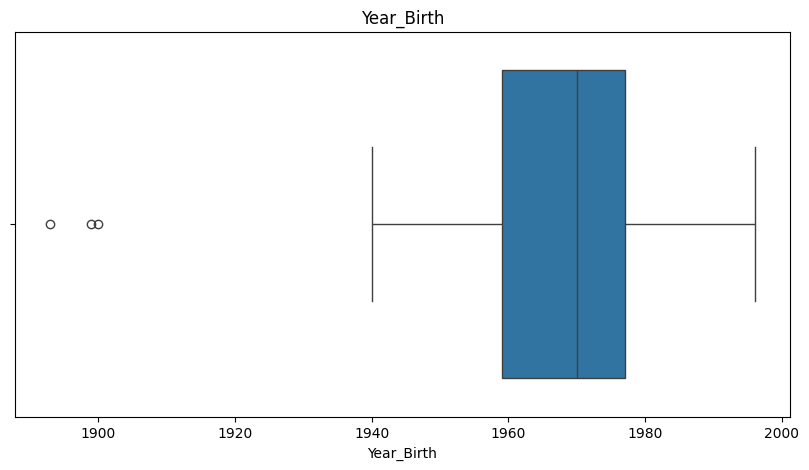

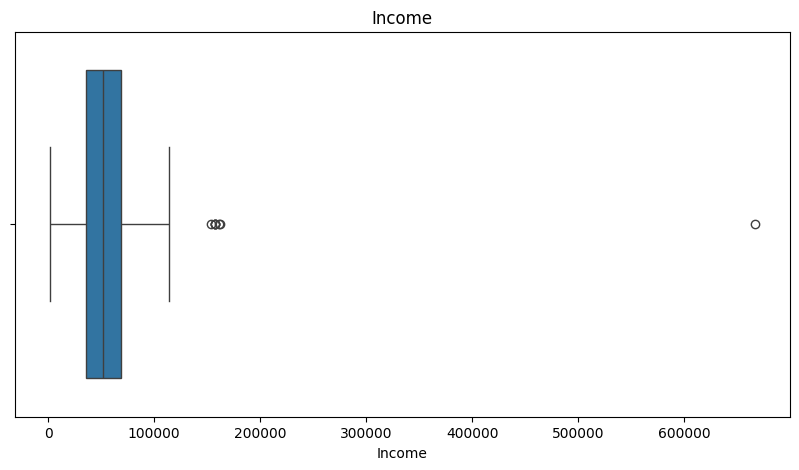

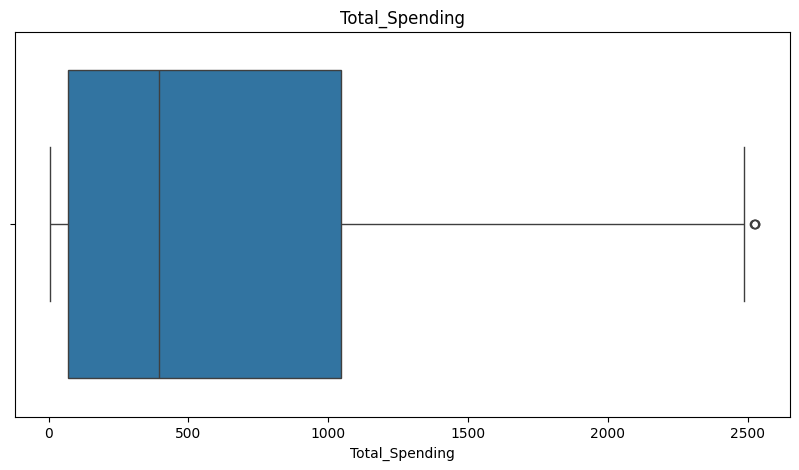

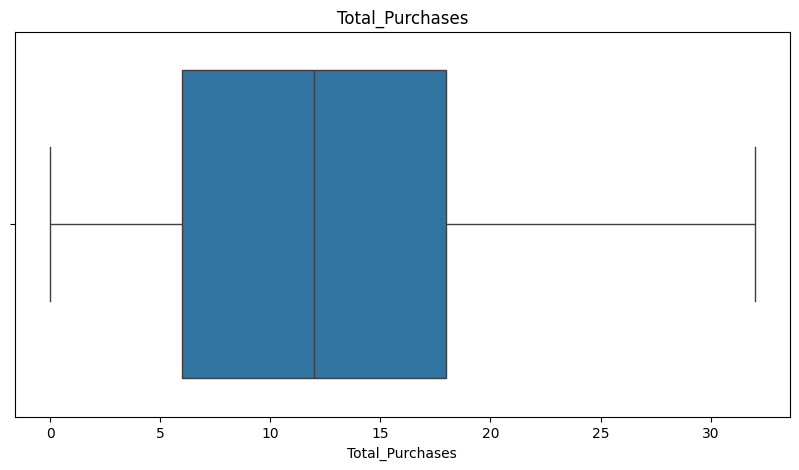

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
cols = ['Year_Birth', 'Income', 'Total_Spending', 'Total_Purchases']

for col in cols:
    print("\n")
    plt.figure(figsize=(10,5))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [24]:
pd.Series(labels).value_counts()

,count
0,1167
2,1072
1,1


In [25]:
X[X['labels'] == 1]

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Married,Single,Together,Widow,YOLO,Customer_Year,Customer_Registration_Days,Total_Spending,Total_Purchases,labels
2233,1977,666666.0,1,0,23,9,14,18,8,1,...,0.0,0.0,1.0,0.0,0.0,2013,392,62,7,1


In [26]:
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1

outliers_mask_income = (df['Income'] < Q1 - 1.5*IQR) | (df['Income'] > Q3 + 1.5*IQR)
print(f'Кількість викидів: {outliers_mask_income.sum()}')

Кількість викидів: 8


In [27]:
X[outliers_mask_income]

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Married,Single,Together,Widow,YOLO,Customer_Year,Customer_Registration_Days,Total_Spending,Total_Purchases,labels
164,1973,157243.0,0,1,98,20,2,1582,1,2,...,1.0,0.0,0.0,0.0,0.0,2014,120,1608,22,2
617,1976,162397.0,1,1,31,85,1,16,2,1,...,0.0,0.0,1.0,0.0,0.0,2013,391,107,1,2
655,1975,153924.0,0,0,81,1,1,1,1,1,...,0.0,0.0,0.0,0.0,0.0,2014,142,6,0,2
687,1982,160803.0,0,0,21,55,16,1622,17,3,...,1.0,0.0,0.0,0.0,0.0,2012,694,1717,29,2
1300,1971,157733.0,1,0,37,39,1,9,2,0,...,0.0,0.0,1.0,0.0,0.0,2013,390,59,2,2
1653,1977,157146.0,0,0,13,1,0,1725,2,1,...,0.0,0.0,1.0,0.0,0.0,2013,426,1730,28,2
2132,1949,156924.0,0,0,85,2,1,2,1,1,...,1.0,0.0,0.0,0.0,0.0,2013,304,8,0,2
2233,1977,666666.0,1,0,23,9,14,18,8,1,...,0.0,0.0,1.0,0.0,0.0,2013,392,62,7,1


In [28]:
X[outliers_mask_income][['Income', 'Total_Spending', 'Total_Purchases']]

,Income,Total_Spending,Total_Purchases
164,157243.0,1608,22
617,162397.0,107,1
655,153924.0,6,0
687,160803.0,1717,29
1300,157733.0,59,2
1653,157146.0,1730,28
2132,156924.0,8,0
2233,666666.0,62,7


Викиди по Income видаляти не будемо, а зробимо заміну значень. Заміну будемо проводити в копії основного дата сету. В наступних пунктах проведемо повторну обробку числових та категоріальних даних.

In [29]:
df_cleaned = df.copy()
upper = df_cleaned['Income'].quantile(0.99)
df_cleaned['Income'] = df_cleaned['Income'].clip(upper=upper)

In [30]:
Q1 = df_cleaned['Total_Spending'].quantile(0.25)
Q3 = df_cleaned['Total_Spending'].quantile(0.75)
IQR = Q3 - Q1

outliers_mask_spending = (df_cleaned['Total_Spending'] < Q1 - 1.5*IQR) | (df_cleaned['Total_Spending'] > Q3 + 1.5*IQR)
print(f'Кількість викидів по  Total_Spending: {outliers_mask_spending.sum()}')

Кількість викидів по  Total_Spending: 3


In [31]:
X[outliers_mask_spending]

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Married,Single,Together,Widow,YOLO,Customer_Year,Customer_Registration_Days,Total_Spending,Total_Purchases,labels
1179,1991,90638.0,0,0,29,1156,120,915,94,144,...,0.0,1.0,0.0,0.0,0.0,2014,136,2525,17,2
1492,1988,87679.0,0,0,62,1259,172,815,97,148,...,0.0,0.0,1.0,0.0,0.0,2013,337,2524,28,2
1572,1991,90638.0,0,0,29,1156,120,915,94,144,...,0.0,1.0,0.0,0.0,0.0,2014,136,2525,17,2


In [32]:
X[outliers_mask_spending][['Income', 'Total_Spending', 'Total_Purchases']]

,Income,Total_Spending,Total_Purchases
1179,90638.0,2525,17
1492,87679.0,2524,28
1572,90638.0,2525,17


Схоже, що викиди по Total_Spending є нормою, тому є сенс залишити ці записи, як є.

In [33]:
Q1 = df_cleaned['Year_Birth'].quantile(0.25)
Q3 = df_cleaned['Year_Birth'].quantile(0.75)
IQR = Q3 - Q1

outliers_mask_year_birth = (df_cleaned['Year_Birth'] < Q1 - 1.5*IQR) | (df_cleaned['Year_Birth'] > Q3 + 1.5*IQR)
print(f'Кількість викидів по  Year_Birth: {outliers_mask_year_birth.sum()}')

Кількість викидів по  Year_Birth: 3


In [34]:
df_cleaned[outliers_mask_year_birth]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Divorced,Married,Single,Together,Widow,YOLO,Customer_Year,Customer_Registration_Days,Total_Spending,Total_Purchases
192,7829,1900,2n Cycle,Divorced,36640.0,1,0,2013-09-26,99,15,...,1.0,0.0,0.0,0.0,0.0,0.0,2013,276,65,5
239,11004,1893,2n Cycle,Single,60182.0,0,1,2014-05-17,23,8,...,0.0,0.0,1.0,0.0,0.0,0.0,2014,43,22,3
339,1150,1899,PhD,Together,83532.0,0,0,2013-09-26,36,755,...,0.0,0.0,0.0,1.0,0.0,0.0,2013,276,1853,14


Враховуючи малу кількість записів, проведемо їх видалення.

In [35]:
df_cleaned = df_cleaned[~outliers_mask_year_birth]

**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

In [36]:
X_cleaned = df_cleaned.drop(columns=['ID', 'Z_Revenue', 'Z_CostContact', 'Education', 'Marital_Status', 'Dt_Customer']).copy()
X_cleaned_scaled = X_cleaned.copy()
scaler = StandardScaler()
X_cleaned_scaled[numeric_cols] = scaler.fit_transform(X_cleaned_scaled[numeric_cols])

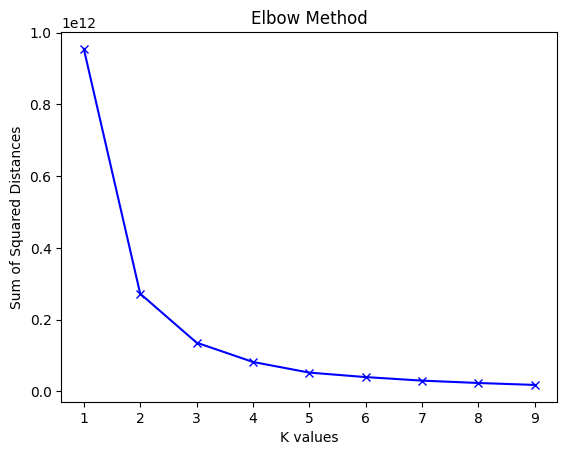

In [37]:
# для очищених  даних (без масштабування)
K = range(1,10)
sum_of_squared_distances = []

for k in K:
    model = KMeans(n_clusters=k, n_init='auto').fit(X_cleaned)
    sum_of_squared_distances.append(model.inertia_)

plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('K values')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method')
plt.show()

In [38]:
# для очищених  даних (без масштабування)
for k in [2, 3, 4]:
    model = KMeans(n_clusters=k, n_init='auto', random_state=42).fit(X_cleaned)
    labels_k = model.predict(X_cleaned)
    s = metrics.silhouette_score(X_cleaned, labels_k)
    print(f'k={k}: silhouette={s:.2f}')

k=2: silhouette=0.60
k=3: silhouette=0.55
k=4: silhouette=0.53


Оскільки значення метрики для k=2 є більшим, то його і візьмемо для побудови фінальної моделі.

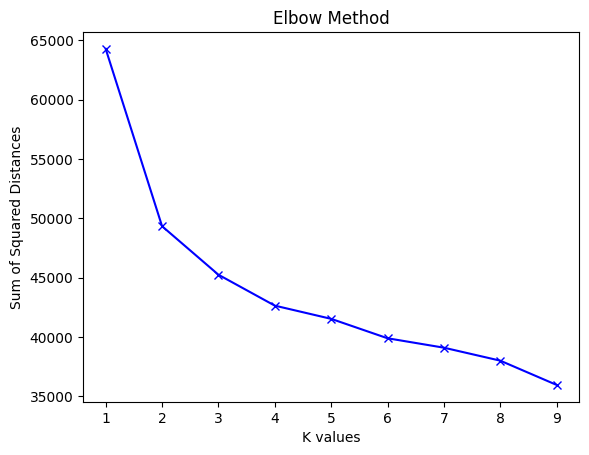

In [39]:
# для очищених та масштабованих даних
K = range(1,10)
sum_of_squared_distances = []

for k in K:
    model = KMeans(n_clusters=k, n_init='auto').fit(X_cleaned_scaled)
    sum_of_squared_distances.append(model.inertia_)

plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('K values')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method')
plt.show()

In [40]:
# для очищених та масштабованих даних
for k in [2, 3, 4]:
    model = KMeans(n_clusters=k, n_init='auto', random_state=42).fit(X_cleaned_scaled)
    labels_k = model.predict(X_cleaned_scaled)
    s = metrics.silhouette_score(X_cleaned_scaled, labels_k)
    print(f'k={k}: silhouette={s:.2f}')

k=2: silhouette=0.25
k=3: silhouette=0.25
k=4: silhouette=0.18


Оскліьки значення метрики для 2 та 3 кластерів однакова, то для фінального навчання та побудови візуалізації оберемо n_clusters=2.

In [41]:
kmeans_cleaned = KMeans(n_clusters=2, n_init='auto', random_state=42)
kmeans_cleaned.fit(X_cleaned)
labels_cleaned= kmeans_cleaned.predict(X_cleaned)

In [42]:
fig = px.scatter_3d(
    X_cleaned,
    x='Income',
    y='Total_Purchases',
    z='Total_Spending',
    color=labels_cleaned.astype(str),
    title='Розподіл клієнтів за доходом, кількістю покупок, загальними витратами (без масштабування)',
    opacity=0.7,
    labels={
        'Income': 'Дохід',
        'Total_Purchases': 'Кількість покупок',
        'Total_Spending': 'Загальні витрати',
        'color': 'Кластер'
    }
)
fig.show()

In [43]:
fig = px.scatter_3d(
    X_cleaned,
    x='Year_Birth',
    y='Total_Purchases',
    z='Total_Spending',
    color=labels_cleaned.astype(str),
    title='Розподіл клієнтів за роком народження, кількістю покупок, загальними витратами (з масштабуванням)',
    opacity=0.7,
    labels={
        'Year_Birth': 'Рік народження',
        'Total_Purchases': 'Кількість покупок',
        'Total_Spending': 'Загальні витрати',
        'color': 'Кластер'
    }
)
fig.show()

In [44]:
kmeans_cleaned_scaled = KMeans(n_clusters=2, n_init='auto', random_state=42)
kmeans_cleaned_scaled.fit(X_cleaned_scaled)
labels_cleaned_scaled= kmeans_cleaned_scaled.predict(X_cleaned_scaled)

In [45]:
fig = px.scatter_3d(
    X_cleaned_scaled,
    x='Income',
    y='Total_Purchases',
    z='Total_Spending',
    color=labels_cleaned_scaled.astype(str),
    title='Розподіл клієнтів за доходом, кількістю покупок, загальними витратами (з масштабуванням)',
    opacity=0.7,
    labels={
        'Income': 'Дохід',
        'Total_Purchases': 'Кількість покупок',
        'Total_Spending': 'Загальні витрати',
        'color': 'Кластер'
    }
)
fig.show()

In [46]:
fig = px.scatter_3d(
    X_cleaned_scaled,
    x='Year_Birth',
    y='Total_Purchases',
    z='Total_Spending',
    color=labels_cleaned_scaled.astype(str),
    title='Розподіл клієнтів за роком народження, кількістю покупок, загальними витратами (з масштабуванням)',
    opacity=0.7,
    labels={
        'Year_Birth': 'Рік народження',
        'Total_Purchases': 'Кількість покупок',
        'Total_Spending': 'Загальні витрати',
        'color': 'Кластер'
    }
)
fig.show()

**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

In [47]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

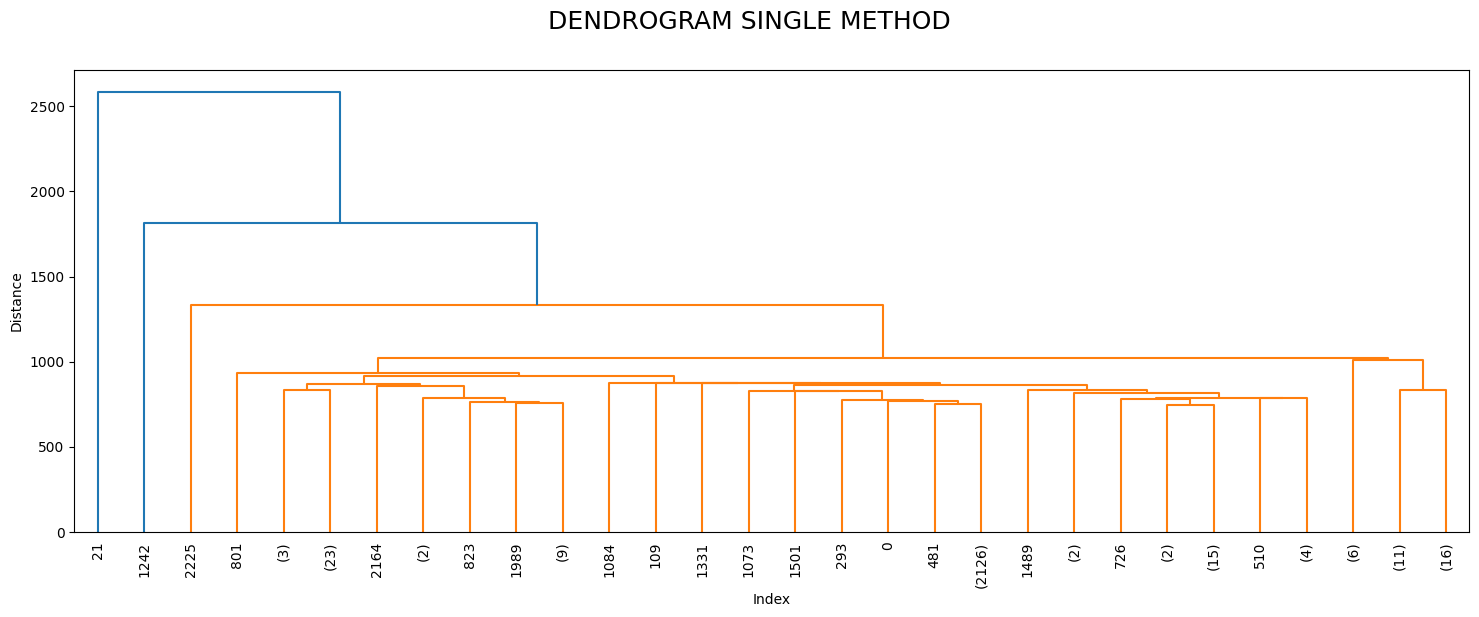

In [48]:
# для очищених  даних (без масштабування)
dist_sin = linkage(X_cleaned, method="single")
plt.figure(figsize=(18,6))
dendrogram(dist_sin, truncate_mode='lastp', leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("DENDROGRAM SINGLE METHOD",fontsize=18)
plt.show()

In [49]:
X_cleaned.loc[[21, 1242]][['Income', 'Total_Spending', 'Total_Purchases']]

,Income,Total_Spending,Total_Purchases
21,2447.0,1730,28
1242,76624.0,899,22


In [50]:
X_cleaned['Income'].describe()

,Income
count,2237.000000
mean,51740.461171
std,20648.291943
min,1730.000000
25%,35523.000000
50%,51381.500000
75%,68281.000000
max,94437.680000


In [51]:
lower = X_cleaned['Income'].quantile(0.01)
print(X_cleaned[X_cleaned['Income'] < lower]['Income'])

9       5648.0
11      7500.0
21      2447.0
44      7500.0
46      7500.0
238     7500.0
439     7500.0
724     7500.0
774     6835.0
862     7500.0
981     4861.0
1152    7500.0
1245    1730.0
1246    7500.0
1299    7500.0
1328    6560.0
1524    3502.0
1806    7144.0
1846    4023.0
1975    4428.0
2029    7500.0
2214    5305.0
2222    7500.0
Name: Income, dtype: float64


In [52]:
X_cleaned['2_clust'] = fcluster(dist_sin, 2, criterion='maxclust')
X_cleaned['3_clust'] = fcluster(dist_sin, 3, criterion='maxclust')

In [53]:
s_2 = metrics.silhouette_score(X_cleaned, X_cleaned['2_clust'])
print(f'silhouette for 2_clust ={s_2:.2f}')

s_3 = metrics.silhouette_score(X_cleaned, X_cleaned['3_clust'])
print(f'silhouette for 3_clust ={s_3:.2f}')

silhouette for 2_clust =0.42
silhouette for 3_clust =0.42


In [54]:
fig = px.scatter_3d(
    X_cleaned,
    x='Income',
    y='Total_Purchases',
    z='Total_Spending',
    color=X_cleaned['2_clust'].astype(str),
    title='Розподіл клієнтів за доходом, кількістю покупок, загальними витратами (без масштабування) - 2_clust',
    opacity=0.7,
    labels={
        'Income': 'Дохід',
        'Total_Purchases': 'Кількість покупок',
        'Total_Spending': 'Загальні витрати',
        'color': 'Кластер'
    }
)
fig.show()

In [55]:
fig = px.scatter_3d(
    X_cleaned,
    x='Income',
    y='Total_Purchases',
    z='Total_Spending',
    color=X_cleaned['3_clust'].astype(str),
    title='Розподіл клієнтів за доходом, кількістю покупок, загальними витратами (без масштабування) - 3_clust',
    opacity=0.7,
    labels={
        'Income': 'Дохід',
        'Total_Purchases': 'Кількість покупок',
        'Total_Spending': 'Загальні витрати',
        'color': 'Кластер'
    }
)
fig.show()

***Висновок:***

- Метод побудови ієрархічної агломеративної кластеризації з single linkage виявився непридатним для кластеризації датасету з невідмасштабованими даними. Замість змістовних кластерів алгоритм відокремив лише два записи, залишивши всі інші точки в одному великому кластері. При цьому один з відокремлених записів підозріло схожий на викид, хоча статистично він не був виявлений в попередніх завданнях.
- Побудовані варіанти плоских кластеризацій з fcluster на 2 і 3 кластери дали аналогічний результат - по одній точці в окремому кластері, а всі інші разом в іншому.

**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте мер=трику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

Застосуємо алгоритм кластерізації DBSCAN до очищених та масштабованих даних.

Для початку підберемо параметри моделі:

In [56]:
from sklearn.cluster import DBSCAN

for eps in [5.0, 7.0, 10.0, 15.0, 20.0]:
    db = DBSCAN(eps=eps, min_samples=10).fit(X_cleaned_scaled)
    n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
    n_noise = (db.labels_ == -1).sum()
    print(f'eps={eps}: кластерів={n_clusters}, викидів={n_noise}')



eps=5.0: кластерів=2, викидів=161
eps=7.0: кластерів=3, викидів=21
eps=10.0: кластерів=2, викидів=0
eps=15.0: кластерів=1, викидів=0
eps=20.0: кластерів=1, викидів=0


In [57]:
dbscan = DBSCAN(eps=10, min_samples=10)
dbscan.fit(X_cleaned_scaled)
labels_db = dbscan.labels_

s_scaled_db = metrics.silhouette_score(X_cleaned_scaled, labels_db, metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters: {s_scaled_db:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.45


Для полегшення інтерпретації отриманих результатів побудує графіки на немасштабованих даних, але з мітками кластерів вище.

In [58]:
X_cleaned = X_cleaned.drop(columns=['2_clust', '3_clust'])

In [59]:
fig = px.scatter_3d(
    X_cleaned,
    x='Income',
    y='Total_Purchases',
    z='Total_Spending',
    color=labels_db.astype(str),
    title='Розподіл клієнтів за доходом, кількістю покупок, загальними витратами - DBSCAN',
    opacity=0.7,
    labels={
        'Income': 'Дохід',
        'Total_Purchases': 'Кількість покупок',
        'Total_Spending': 'Загальні витрати',
        'color': 'Кластер'
    }
)
fig.show()

In [60]:
fig = px.scatter_3d(
    X_cleaned,
    x='Year_Birth',
    y='Total_Purchases',
    z='Total_Spending',
    color=labels_db.astype(str),
    title='Розподіл клієнтів за роком народження, кількістю покупок, загальними витратами - DBSCAN',
    opacity=0.7,
    labels={
        'Year_Birth': 'Рік народження',
        'Total_Purchases': 'Кількість покупок',
        'Total_Spending': 'Загальні витрати',
        'color': 'Кластер'
    }
)
fig.show()

***Висновок:***
- Алгоритм кластерізації DBSCAN знайшов 2 кластери. Розділення даних на кластери не має чіткої логіки. Вважаю, що ця кластерізація не є корисною. Для покращення результату потрібно було б зменшити кількість ознак.